# 02. Прогнозирование уровня тревожности

Регрессионные модели для предсказания GAD-7 оценки.

**Модели:** RandomForest, LightGBM, CatBoost, Ridge
**Тюнинг:** Optuna + GridSearchCV
**Особенности:** Log-target, Bagging, SHAP

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

In [20]:
%pip install -q optuna

In [21]:
import optuna

## Загрузка данных

In [22]:
EXTRA_FILE_PATH = '/content/drive/MyDrive/' # Google Drive (if used)

## Google Drive

Загрузка / выгрузка диска

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
df = pd.read_csv(EXTRA_FILE_PATH + 'data/processed_data.csv')

TARGET = 'Anxiety_Level'
FEATURES = [c for c in df.columns if c not in [TARGET, 'Subjective_Anxiety']]

X = df[FEATURES]
y = df[TARGET]

print(f"Features: {len(FEATURES)}, Samples: {len(y)}")
print(f"Target range: {y.min()} - {y.max()}")

Features: 16, Samples: 433
Target range: 0 - 21


## Разбиение данных

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=pd.qcut(y, q=5, labels=False, duplicates='drop')
)

y_strat = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 346, Test: 87


## Вспомогательные функции

In [26]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name=''):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    n, p = len(y_test), X_test.shape[1]
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"\n{name}")
    print(f"  MAE: {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²: {r2:.3f}")
    print(f"  Adj R²: {adj_r2:.3f}")

    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'adj_r2': adj_r2, 'predictions': y_pred, 'model': model}

In [27]:
def log_evaluate_model(model, X_train, X_test, y_train, y_test, name=''):
    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    model.fit(X_train, y_train_log)
    y_pred_log = model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"  MAE: {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R²: {r2:.3f}")

    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'predictions': y_pred, 'model': model}

## Baseline: Ridge Regression

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0, random_state=42)
ridge_results = evaluate_model(ridge, X_train_scaled, X_test_scaled, y_train, y_test, 'Ridge Regression')


Ridge Regression
  MAE: 2.870
  RMSE: 3.712
  R²: 0.363
  Adj R²: 0.218


### Ridge Regression: GridSearchCV
Так как Ridge показал хорошие метрики, поищем наилучшие параметры

In [29]:
params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

search = GridSearchCV(Ridge(random_state=42), params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
search.fit(X_train, y_train)
print("Лучший alpha:", search.best_params_)
grid_ridge_results = evaluate_model(ridge, X_train_scaled, X_test_scaled, y_train, y_test, 'Ridge Regression')


Лучший alpha: {'alpha': 10}

Ridge Regression
  MAE: 2.870
  RMSE: 3.712
  R²: 0.363
  Adj R²: 0.218


## Random Forest: GridSearchCV

In [30]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'min_samples_leaf': [3, 5, 7],
    'min_samples_split': [4, 6, 8]
}

grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1
)
grid_search.fit(X_train, y_train)

rf_grid_results = evaluate_model(
    grid_search.best_estimator_, X_train, X_test, y_train, y_test,
    'Random Forest (GridSearch)'
)

print(f"Best params: {grid_search.best_params_}")


Random Forest (GridSearch)
  MAE: 2.956
  RMSE: 3.869
  R²: 0.309
  Adj R²: 0.151
Best params: {'max_depth': 5, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 50}


## Random Forest: Optuna с Gap Penalty

In [ ]:
def objective_rf_gap(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestRegressor(**params)

    train_scores, val_scores = [], []
    for train_idx, val_idx in stratified_cv.split(X_train, y_strat):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        train_scores.append(mean_absolute_error(y_tr, model.predict(X_tr)))
        val_scores.append(mean_absolute_error(y_val, model.predict(X_val)))

    train_mae = np.mean(train_scores)
    val_mae = np.mean(val_scores)
    gap_penalty = max(0, val_mae - train_mae) * 0.5

    return val_mae + gap_penalty

study_rf = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(objective_rf_gap, n_trials=50, show_progress_bar=True)

print(f"\nBest MAE: {study_rf.best_value:.3f}")
print(f"Best params: {study_rf.best_params}")

In [32]:
rf_optuna = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
rf_opt_results = evaluate_model(rf_optuna, X_train, X_test, y_train, y_test, 'Random Forest + Optuna')


Random Forest + Optuna
  MAE: 2.870
  RMSE: 3.714
  R²: 0.363
  Adj R²: 0.217


## LightGBM

In [ ]:
import lightgbm as lgb

def objective_lgb(trial):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 8, 64),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42
    }

    model = lgb.LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return -np.mean(scores)

study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)

print(f"\nBest MAE: {study_lgb.best_value:.3f}")

In [34]:
lgb_model = lgb.LGBMRegressor(**study_lgb.best_params, verbosity=-1, random_state=42)
lgb_results = evaluate_model(lgb_model, X_train, X_test, y_train, y_test, 'LightGBM + Optuna')


LightGBM + Optuna
  MAE: 2.870
  RMSE: 3.703
  R²: 0.366
  Adj R²: 0.222


## LightGBM: Bagging (Ensemble)

In [35]:
def train_bagging_cv(model_class, params, X_train, y_train, stratified_cv, y_strat):
    models = []
    oof_preds = np.zeros(len(X_train))  # массив для out-of-fold предсказаний

    for train_idx, val_idx in stratified_cv.split(X_train, y_strat):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = model_class(**params)
        model.fit(X_tr, y_tr)
        models.append(model)
        oof_preds[val_idx] = model.predict(X_val)  # заполняем по индексам

    return models, oof_preds

lgb_params = {**study_lgb.best_params, 'verbosity': -1, 'random_state': 42}
lgb_models, lgb_cv_preds = train_bagging_cv(lgb.LGBMRegressor, lgb_params, X_train, y_train, stratified_cv, y_strat)

test_preds = np.array([m.predict(X_test) for m in lgb_models])
lgb_bagging_preds = np.mean(test_preds, axis=0)

mae = mean_absolute_error(y_test, lgb_bagging_preds)
rmse = np.sqrt(mean_squared_error(y_test, lgb_bagging_preds))
r2 = r2_score(y_test, lgb_bagging_preds)

print(f"\nLightGBM Bagging Ensemble")
print(f"  MAE: {mae:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  R²: {r2:.3f}")


LightGBM Bagging Ensemble
  MAE: 2.871
  RMSE: 3.683
  R²: 0.374


## LightGBM: Log-Target + Bagging

In [ ]:
y_train_log = np.log1p(y_train)

def objective_lgb_log(trial):
    params = {
        'objective': 'regression',
        'metric': 'mae',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 8, 64),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'random_state': 42
    }

    model = lgb.LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, y_train_log, cv=5, scoring='neg_mean_absolute_error')
    return -np.mean(scores)

study_lgb_log = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb_log.optimize(objective_lgb_log, n_trials=50, show_progress_bar=True)

print(f"\nBest Log MAE: {study_lgb_log.best_value:.3f}")

In [37]:
lgb_log_params = {**study_lgb_log.best_params, 'verbosity': -1, 'random_state': 42}
lgb_log_models = []
lgb_log_test_preds = []

for train_idx, val_idx in stratified_cv.split(X_train, y_strat):
    X_tr, y_tr = X_train.iloc[train_idx], y_train_log.iloc[train_idx]
    model = lgb.LGBMRegressor(**lgb_log_params)
    model.fit(X_tr, y_tr)
    lgb_log_models.append(model)
    lgb_log_test_preds.append(model.predict(X_test))

lgb_log_bagging_preds = np.expm1(np.mean(lgb_log_test_preds, axis=0))

mae = mean_absolute_error(y_test, lgb_log_bagging_preds)
rmse = np.sqrt(mean_squared_error(y_test, lgb_log_bagging_preds))
r2 = r2_score(y_test, lgb_log_bagging_preds)

print(f"\nLightGBM Log-Target + Bagging")
print(f"  MAE: {mae:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  R²: {r2:.3f}")

lgb_log_results = {'mae': mae, 'rmse': rmse, 'r2': r2, 'predictions': lgb_log_bagging_preds}


LightGBM Log-Target + Bagging
  MAE: 3.086
  RMSE: 3.962
  R²: 0.275


## CatBoost

In [38]:
%pip install -q catboost

In [ ]:
from catboost import CatBoostRegressor

def objective_cat(trial):
    params = {
        'loss_function': 'MAE',
        'iterations': trial.suggest_int('iterations', 50, 300),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10.0, log=True),
        'random_seed': 42,
        'verbose': 0
    }

    model = CatBoostRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    return -np.mean(scores)

study_cat = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(objective_cat, n_trials=30, show_progress_bar=True)

print(f"\nBest MAE: {study_cat.best_value:.3f}")

In [40]:
cat_model = CatBoostRegressor(**study_cat.best_params, random_seed=42, verbose=0)
cat_results = evaluate_model(cat_model, X_train, X_test, y_train, y_test, 'CatBoost + Optuna')


CatBoost + Optuna
  MAE: 2.793
  RMSE: 3.647
  R²: 0.386
  Adj R²: 0.245


## CatBoost: Log-Target + Bagging

In [41]:
cat_log_params = {**study_cat.best_params, 'random_seed': 42, 'verbose': 0}
cat_log_models = []
cat_log_test_preds = []

for train_idx, val_idx in stratified_cv.split(X_train, y_strat):
    X_tr, y_tr = X_train.iloc[train_idx], y_train_log.iloc[train_idx]
    model = CatBoostRegressor(**cat_log_params)
    model.fit(X_tr, y_tr)
    cat_log_models.append(model)
    cat_log_test_preds.append(model.predict(X_test))

cat_log_bagging_preds = np.expm1(np.mean(cat_log_test_preds, axis=0))

mae = mean_absolute_error(y_test, cat_log_bagging_preds)
rmse = np.sqrt(mean_squared_error(y_test, cat_log_bagging_preds))
r2 = r2_score(y_test, cat_log_bagging_preds)

print(f"\nCatBoost Log-Target + Bagging")
print(f"  MAE: {mae:.3f}")
print(f"  RMSE: {rmse:.3f}")
print(f"  R²: {r2:.3f}")

cat_log_results = {'mae': mae, 'rmse': rmse, 'r2': r2, 'predictions': cat_log_bagging_preds}


CatBoost Log-Target + Bagging
  MAE: 3.075
  RMSE: 3.951
  R²: 0.279


## Сравнение моделей

In [42]:
results = pd.DataFrame({
    'Model': ['Ridge', 'Ridge GridSearch', 'RF GridSearch', 'RF Optuna', 'LightGBM',
              'LightGBM Bagging', 'LightGBM Log+Bag', 'CatBoost', 'CatBoost Log+Bag'],
    'MAE': [ridge_results['mae'], grid_ridge_results['mae'], rf_grid_results['mae'], rf_opt_results['mae'],
            lgb_results['mae'], mae, lgb_log_results['mae'],
            cat_results['mae'], cat_log_results['mae']],
    'RMSE': [ridge_results['rmse'], grid_ridge_results['rmse'], rf_grid_results['rmse'], rf_opt_results['rmse'],
             lgb_results['rmse'], rmse, lgb_log_results['rmse'], 
             cat_results['rmse'], cat_log_results['rmse']],
    'R²': [ridge_results['r2'], grid_ridge_results["r2"], rf_grid_results['r2'], rf_opt_results['r2'],
            lgb_results['r2'], r2, lgb_log_results['r2'],
            cat_results['r2'], cat_log_results['r2']]
})
results = results.sort_values('MAE')
print(results.to_string(index=False))

           Model      MAE     RMSE       R²
        CatBoost 2.792695 3.647171 0.385547
       RF Optuna 2.869859 3.714202 0.362754
Ridge GridSearch 2.869927 3.712166 0.363452
           Ridge 2.869927 3.712166 0.363452
        LightGBM 2.870226 3.703394 0.366457
   RF GridSearch 2.956232 3.868885 0.308571
LightGBM Bagging 3.074949 3.951190 0.278840
CatBoost Log+Bag 3.074949 3.951190 0.278840
LightGBM Log+Bag 3.085837 3.962169 0.274826


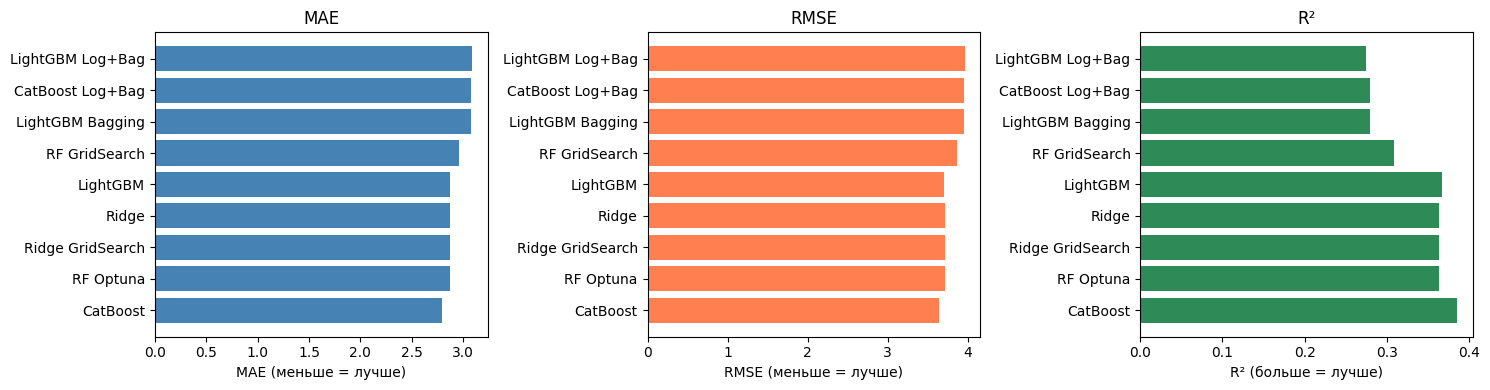

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].barh(results['Model'], results['MAE'], color='steelblue')
axes[0].set_xlabel('MAE (меньше = лучше)')
axes[0].set_title('MAE')

axes[1].barh(results['Model'], results['RMSE'], color='coral')
axes[1].set_xlabel('RMSE (меньше = лучше)')
axes[1].set_title('RMSE')

axes[2].barh(results['Model'], results['R²'], color='seagreen')
axes[2].set_xlabel('R² (больше = лучше)')
axes[2].set_title('R²')

plt.tight_layout()
plt.show()

## Feature Importance (Catboost)

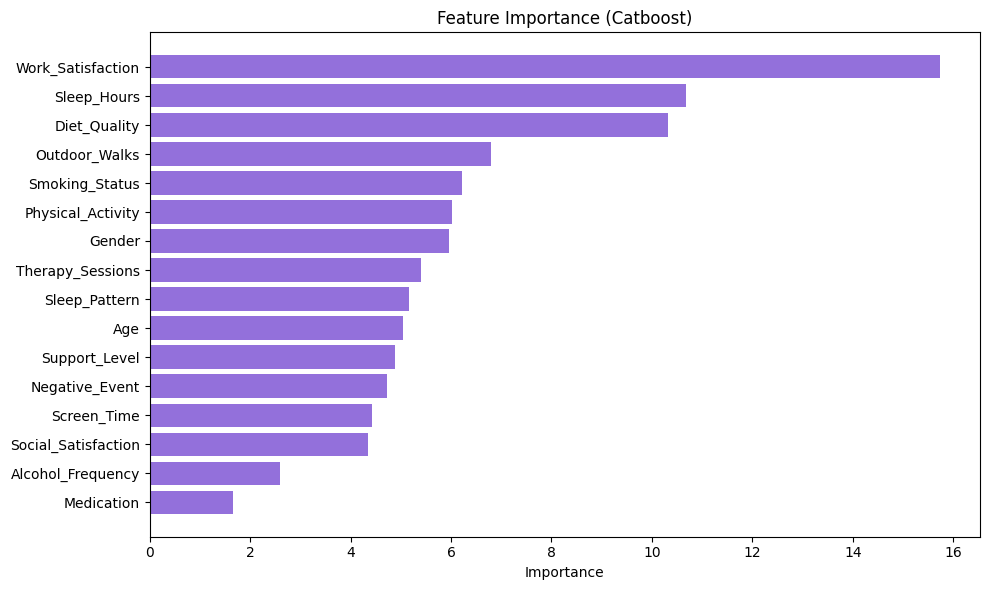

In [50]:
cat_model.fit(X_train, y_train)
importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': cat_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importance['feature'], importance['importance'], color='mediumpurple')
plt.xlabel('Importance')
plt.title('Feature Importance (Catboost)')
plt.tight_layout()
plt.show()

## SHAP Analysis (Catboost)

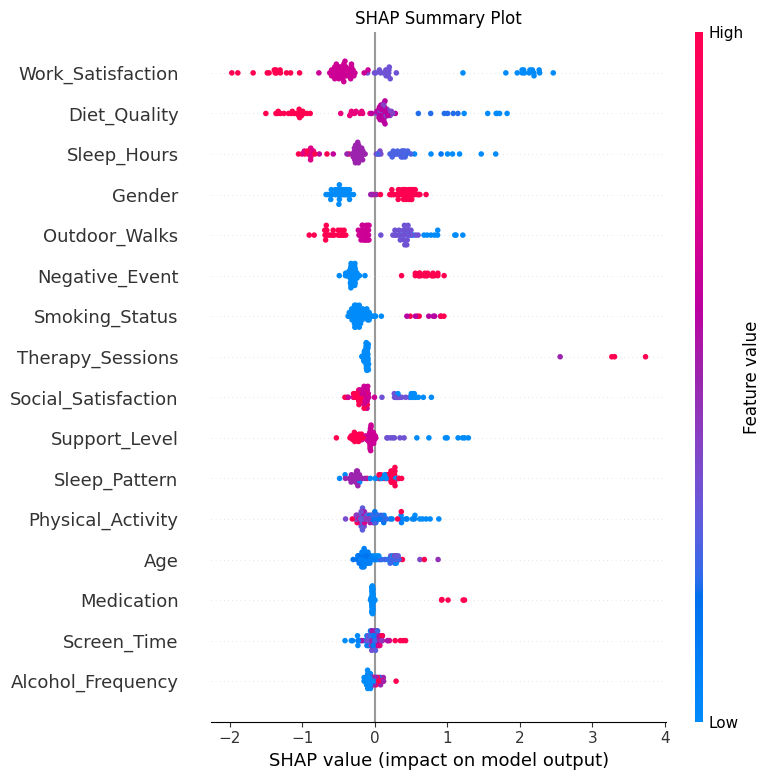

In [47]:
import shap

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False)
plt.title('SHAP Summary Plot')
plt.tight_layout()
plt.show()

## Сохранение лучшей модели

In [46]:
import joblib

best_idx = results['MAE'].idxmin()
best_model_name = results.loc[best_idx, 'Model']
print(f"Best model: {best_model_name}")

model_map = {
    'LightGBM Log+Bag': (lgb_log_models, 'log_bagging'),
    'CatBoost Log+Bag': (cat_log_models, 'log_bagging'),
    'LightGBM': (lgb_model, 'single'),
    'CatBoost': (cat_model, 'single'),
    'RF Optuna': (rf_optuna, 'single'),
    'RF GridSearch': (grid_search.best_estimator_, 'single'),
    'Ridge GridSearch': (search.best_estimator_, 'single')   
}

joblib.dump(model_map.get(best_model_name, (lgb_model, 'single'))[0], EXTRA_FILE_PATH+'models/best_model.pkl')
print(f"Model saved: models/best_model.pkl")

Best model: CatBoost
Model saved: models/best_model.pkl
